### Analysis of an E-commerce Dataset

This project analyzes an e-commerce dataset containing user ratings,
reviews, and product information. The objective is to explore rating
patterns, perform descriptive statistics, visualize trends, and detect
outliers in the dataset.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [9]:
df = pd.read_csv('The E-commerce Dataset.csv')
df.head()

,userId,timestamp,review,item,rating,helpfulness,gender,category,item_id,item_price,user_city
0,4051,12807,Great job for what it is!,eBay,5.0,2.0,F,Online Stores & Services,88,149.00,39
1,4052,122899,Free Access Worth your Time,NetZero,5.0,0.0,F,Online Stores & Services,46,53.00,39
2,33,12700,AOL..I love you!!!!!!!!!!!!,AOL (America Online),5.0,4.0,F,Online Stores & Services,0,145.84,31
3,33,21000,EBAY!!! I LOVE YOU!!!! :-)*,eBay,5.0,4.0,F,Online Stores & Services,88,149.00,31
4,33,22300,Blair Witch...Oh Come On.......,Blair Witch Project,1.0,4.0,F,Movies,12,44.00,31


In [40]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 19983 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   userId       19983 non-null  int64  
 1   timestamp    19983 non-null  int64  
 2   review       19983 non-null  object 
 3   item         19983 non-null  object 
 4   rating       19983 non-null  float64
 5   helpfulness  19961 non-null  float64
 6   gender       19956 non-null  object 
 7   category     19983 non-null  object 
 8   item_id      19983 non-null  int64  
 9   item_price   19983 non-null  float64
 10  user_city    19983 non-null  int64  
dtypes: float64(3), int64(4), object(4)
memory usage: 1.8+ MB


userId          0
timestamp       0
review          0
item            0
rating          0
helpfulness    22
gender         27
category        0
item_id         0
item_price      0
user_city       0
dtype: int64

## Handle Missing Data
Removed rows with missing critical values (`gender`, `userId`, `item_id`, `rating`, `helpfulness`)  
Removed reviews with value 'none'  
Filled missing reviews with 'No Review'

In [19]:
null_count = df.isnull().sum()
print("Missing values before cleaning:\n", null_count)

Missing values before cleaning:
 userId          0
timestamp       0
review          0
item            0
rating         17
helpfulness    22
gender         27
category        0
item_id         0
item_price      0
user_city       0
dtype: int64


In [21]:
df = df.dropna(subset=['userId', 'item_id', 'rating'])

In [23]:
df['review'] = df['review'].fillna("No Review")

## Outlier Removal
Removed reviews with helpfulness ≤ 2  
Removed users with <7 ratings  
Removed items with <11 ratings

In [25]:
# Remove reviews with helpfulness ≤ 2
df1 = df[df['helpfulness'] > 2]

# Remove users who rated less than 7 items
user_item = df1.groupby('userId')['item'].count()
df2 = df1.merge(user_item.reset_index(name='item_count'), on='userId')
df2 = df2[df2['item_count'] >= 7]
df2.drop('item_count', axis=1, inplace=True)

# Remove items with less than 11 ratings
item_ratings = df2.groupby('item_id')['rating'].count()
df3 = df2.merge(item_ratings.reset_index(name='rating_count'), on='item_id')
df3 = df3[df3['rating_count'] >= 11]
df3.drop('rating_count', axis=1, inplace=True)

print("Length of cleaned dataset:", len(df3))
print("Shape of cleaned dataset:", df3.shape)


Length of cleaned dataset: 2697
Shape of cleaned dataset: (2697, 11)


## Descriptive statistics


#### Total number of unique users, reviews, items, and categories
This shows the diversity of users, products, and reviews in the cleaned dataset.

In [ ]:
total_unique_users = df3['userId'].nunique()
print("Total number of unique users:", total_unique_users)

total_unique_review = df3['review'].nunique()
print("Total number of unique review:", total_unique_review)

total_unique_item = df3['item'].nunique()
print("Total number of unique item:", total_unique_item)

total_unique_category = df3['category'].nunique()
print("Total number of unique category:", total_unique_category)


#### Rating statistics
Mean, standard deviation, min, max, and total count of ratings.

In [52]:
descriptive_statistics_mean = df3['rating'].mean()
print("Mean of Rating record:",descriptive_statistics_mean)

descriptive_statistics_std = df3['rating'].std()
print("SD of rating record:",descriptive_statistics_std)

descriptive_statistics_count = df3['rating'].count()
print("Total number of rating record:",descriptive_statistics_count)

descriptive_statistics_max= df3['rating'].max()
print("Max of all rating records:",descriptive_statistics_max)

descriptive_statistics_min = df3['rating'].min()
print("Min of all rating records:",descriptive_statistics_min)

Mean of Rating record: 3.703374119391917
SD of rating record: 1.3468695564877362
Total number of rating record: 2697
Max of all rating records: 5.0
Min of all rating records: 1.0


#### Rating statistics by gender
Shows how average ratings differ across male and female users.

In [54]:
rating_by_gender = df3.groupby('gender')['rating'].describe()
print(rating_by_gender)

         count      mean      std  min  25%  50%  75%  max
gender                                                    
F       1287.0  3.752914  1.34645  1.0  3.0  4.0  5.0  5.0
M       1409.0  3.659333  1.34589  1.0  3.0  4.0  5.0  5.0


#### Ratings per item
Total, mean, max, and min ratings received by each item.

In [62]:
ratings_per_item = df3.groupby("item")["rating"].agg(
    Total='count',
    Mean='mean',
    Max='max',
    Min='min'
).reset_index()

print(ratings_per_item.head())

                   item  Total      Mean  Max  Min
0  AOL (America Online)     94  2.691489  5.0  1.0
1         All Advantage     73  2.986301  5.0  1.0
2            Amazon.com     18  4.333333  5.0  2.0
3     American Airlines     19  3.263158  5.0  1.0
4       American Beauty     45  4.266667  5.0  1.0


## Plotting and Analysis

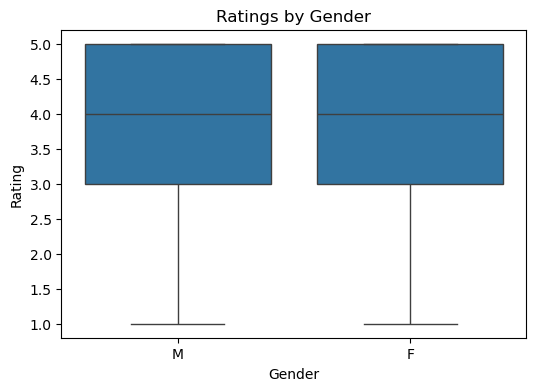

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ratings by Gender
plt.figure(figsize=(6,4))
sns.boxplot(x='gender', y='rating', data=df3)
plt.title('Ratings by Gender')
plt.xlabel('Gender')
plt.ylabel('Rating')
plt.show()

Summary: This barplot is representing the count of rating based on Gender.Both gender have median rating around 4.0 indicated by the green line within each box. This visual data suggests that thereis no significant difference in the ratings between the two genders, as both have similar median ratings and distributionranges.  

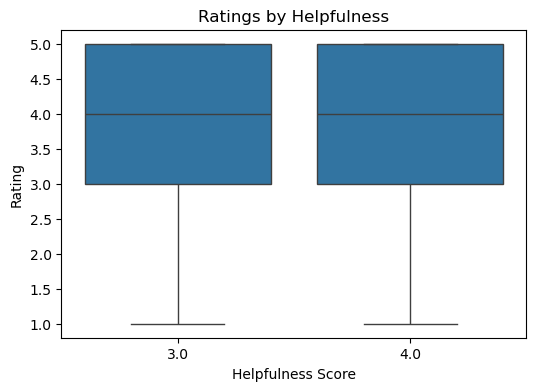

In [88]:
plt.figure(figsize=(6,4))
sns.boxplot(x='helpfulness', y='rating', data=df3)
plt.title('Ratings by Helpfulness')
plt.xlabel('Helpfulness Score')
plt.ylabel('Rating')
plt.show()

Summary: This baeplot represent the count of rating basend on the helpfulness count. As the level of helpfulness increases from 0.0 to 4.0, the maximum ratings also rise, reaching close to or equal to 5. This implies that higher helpfulness is associated with higher ratings.

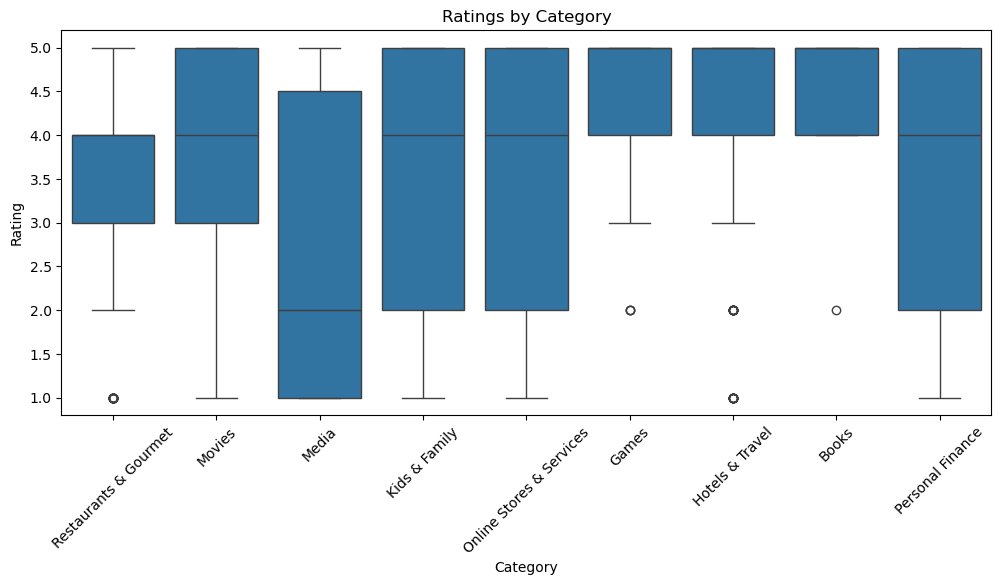

In [82]:
plt.figure(figsize=(12,5))
sns.boxplot(x='category', y='rating', data=df3)
plt.title('Ratings by Category')
plt.xlabel('Category')
plt.ylabel('Rating')
plt.xticks(rotation=45)
plt.show()

Summary:The bar graph and barplot represent the total count of ratings across various caategories.The Book count has the highest total count of 5 rating and books/media have the lowest counts of less than 500 among all the category provided.


## Detect and Remove Outliers

Outliers were removed in three steps:

1. **Reviews with helpfulness ≤ 2** were removed because low helpfulness indicates poor-quality reviews.
2. **Users who rated fewer than 7 items** were removed to focus on more active users.
3. **Items that received fewer than 11 ratings** were removed to ensure statistical reliability.

The final dataset (`df_cleaned`) is ready for descriptive statistics and visualization.

In [99]:
df_outliers1 = df[df['helpfulness'] > 2]
print("After removing reviews with helpfulness <= 2:", df_outliers1.shape)

After removing reviews with helpfulness <= 2: (13678, 11)


In [101]:
user_item_count = df_outliers1.groupby('userId')['item'].count()
df_outliers2 = df_outliers1.merge(
    user_item_count.reset_index(name='item_count'),
    on='userId'
)
df_outliers2 = df_outliers2[df_outliers2['item_count'] >= 7]
df_outliers2.drop('item_count', axis=1, inplace=True)
print("After removing users with <7 ratings:", df_outliers2.shape)


After removing users with <7 ratings: (2753, 11)


In [103]:
item_rating_count = df_outliers2.groupby('item_id')['rating'].count()
df_cleaned = df_outliers2.merge(
    item_rating_count.reset_index(name='rating_count'),
    on='item_id'
)
df_cleaned = df_cleaned[df_cleaned['rating_count'] >= 11]
df_cleaned.drop('rating_count', axis=1, inplace=True)
print("After removing items with <11 ratings:", df_cleaned.shape)

After removing items with <11 ratings: (2697, 11)


In [105]:
print("Length of fully cleaned dataset:", len(df_cleaned))

Length of fully cleaned dataset: 2697


In [107]:
print("Final cleaned dataset shape:", df_cleaned.shape)
print("Total records in final dataset:", len(df_cleaned))

Final cleaned dataset shape: (2697, 11)
Total records in final dataset: 2697


## Conclusion

In this project, an e-commerce dataset containing user reviews, ratings, and product information was analyzed.

First, missing data was handled by removing records with missing values in critical fields such as gender, rating, and helpfulness. Reviews with the value 'none' were also removed to ensure data quality.

Next, descriptive statistics were calculated to understand the number of unique users, items, reviews, and categories in the dataset, as well as the overall distribution of ratings.

Data visualization techniques such as boxplots were used to explore the relationship between ratings and variables such as gender, helpfulness, and product category.

Finally, outliers were detected and removed based on three rules: reviews with low helpfulness scores, users with very few ratings, and items with very few ratings. This resulted in a cleaner dataset suitable for further analysis.

Overall, the analysis provided insights into user rating behavior and product review patterns in the e-commerce dataset.